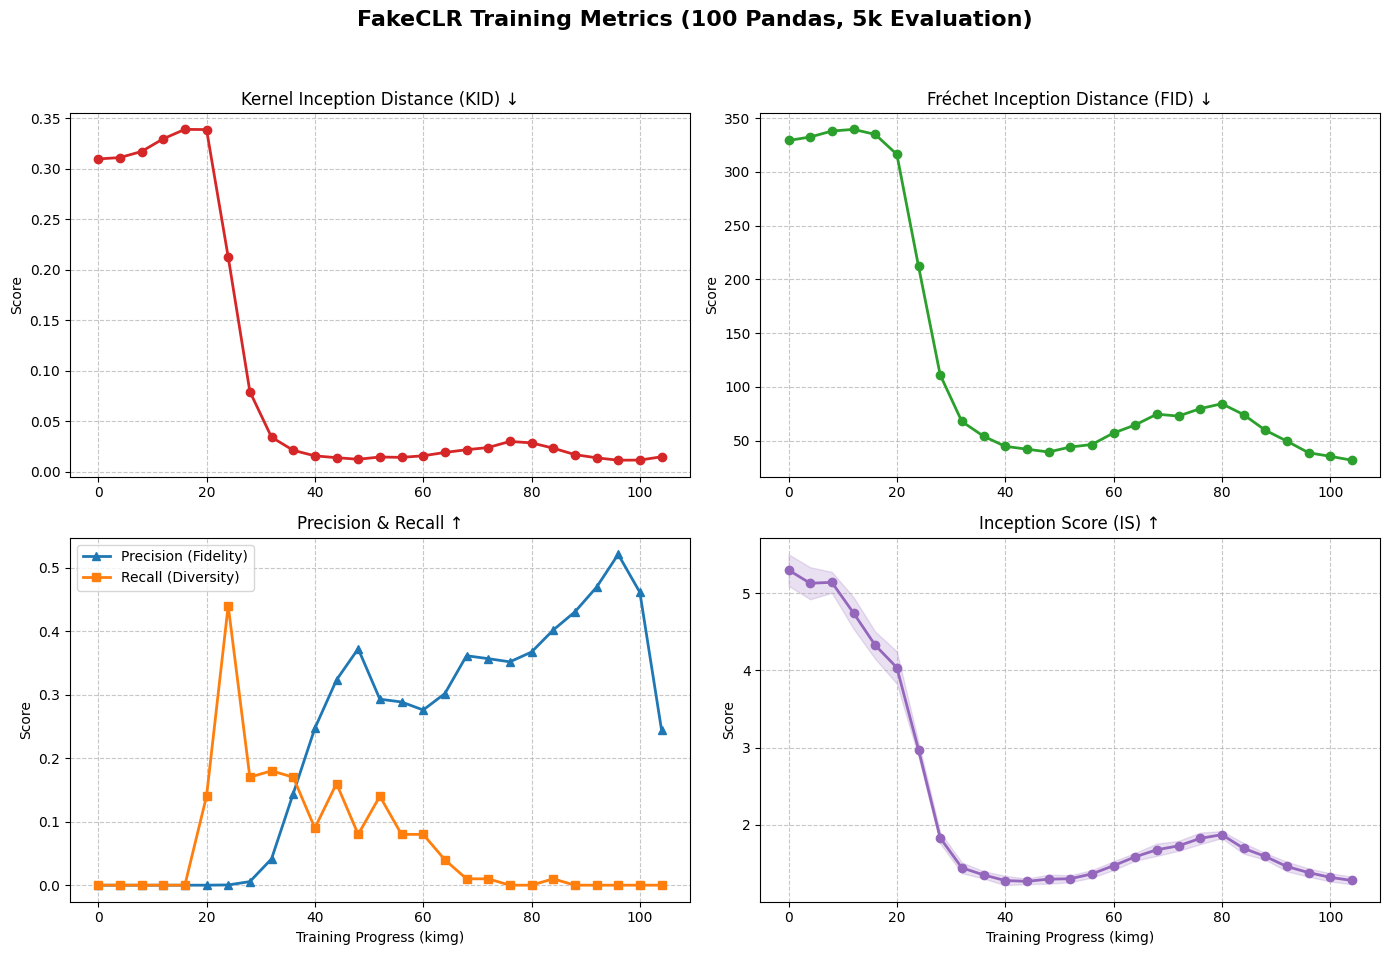

In [1]:
import os
import json
import matplotlib.pyplot as plt

import sys
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))


# --- CONFIGURATION ---
FAKECLR_DIR = os.path.join(BASE_DIR, "src", "FakeCLR", "merged_snapshots")

def load_metric(metric_name, key_names):
    """Reads a JSONL file and returns a dictionary of {kimg: {key: value}}."""
    file_path = os.path.join(FAKECLR_DIR, f"metric-{metric_name}.jsonl")
    data = {}
    
    if not os.path.exists(file_path):
        print(f"Warning: Could not find {file_path}")
        return data

    with open(file_path, 'rt') as f:
        for line in f:
            entry = json.loads(line)
            # Handle absolute paths saved by FakeCLR
            pkl_name = os.path.basename(entry['snapshot_pkl'])
            kimg = int(pkl_name.split('-')[-1].split('.')[0])
            
            data[kimg] = {k: entry['results'][k] for k in key_names}
            
    return data

# --- 1. LOAD ALL DATA ---
clr_kid = load_metric('kid5k_full', ['kid5k_full'])
clr_fid = load_metric('fid5k_full', ['fid5k_full'])
clr_pr  = load_metric('pr5k3_full', ['pr5k3_full_precision', 'pr5k3_full_recall'])
clr_is  = load_metric('is5k',       ['is5k_mean', 'is5k_std'])

# Sort by kimg (X-axis)
kimgs = sorted(list(clr_kid.keys()))

# --- 2. EXTRACT ARRAYS FOR PLOTTING ---
x_kid = sorted(clr_kid.keys())
y_kid = [clr_kid[k]['kid5k_full'] for k in x_kid]

x_fid = sorted(clr_fid.keys())
y_fid = [clr_fid[k]['fid5k_full'] for k in x_fid]

x_pr = sorted(clr_pr.keys())
y_precision = [clr_pr[k]['pr5k3_full_precision'] for k in x_pr]
y_recall    = [clr_pr[k]['pr5k3_full_recall'] for k in x_pr]

x_is = sorted(clr_is.keys())
y_is_mean = [clr_is[k]['is5k_mean'] for k in x_is]
y_is_std  = [clr_is[k]['is5k_std'] for k in x_is]

# --- 3. CREATE THE DASHBOARD ---
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('FakeCLR Training Metrics (100 Pandas, 5k Evaluation)', fontsize=16, fontweight='bold')

# Plot 1: KID (Lower is better)
axs[0, 0].plot(x_kid, y_kid, marker='o', color='#d62728', linewidth=2)
axs[0, 0].set_title('Kernel Inception Distance (KID) ↓')
axs[0, 0].set_ylabel('Score')
axs[0, 0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: FID (Lower is better)
axs[0, 1].plot(x_fid, y_fid, marker='o', color='#2ca02c', linewidth=2)
axs[0, 1].set_title('Fréchet Inception Distance (FID) ↓')
axs[0, 1].set_ylabel('Score')
axs[0, 1].grid(True, linestyle='--', alpha=0.7)

# Plot 3: Precision & Recall (Higher is better)
axs[1, 0].plot(x_pr, y_precision, marker='^', color='#1f77b4', label='Precision (Fidelity)', linewidth=2)
axs[1, 0].plot(x_pr, y_recall, marker='s', color='#ff7f0e', label='Recall (Diversity)', linewidth=2)
axs[1, 0].set_title('Precision & Recall ↑')
axs[1, 0].set_ylabel('Score')
axs[1, 0].set_xlabel('Training Progress (kimg)')
axs[1, 0].legend()
axs[1, 0].grid(True, linestyle='--', alpha=0.7)

# Plot 4: Inception Score (Higher is better)
axs[1, 1].plot(x_is, y_is_mean, marker='o', color='#9467bd', linewidth=2)
axs[1, 1].fill_between(x_is, 
                       [m - s for m, s in zip(y_is_mean, y_is_std)], 
                       [m + s for m, s in zip(y_is_mean, y_is_std)], 
                       color='#9467bd', alpha=0.2)
axs[1, 1].set_title('Inception Score (IS) ↑')
axs[1, 1].set_ylabel('Score')
axs[1, 1].set_xlabel('Training Progress (kimg)')
axs[1, 1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()